<a href="https://colab.research.google.com/github/legardajuanpablo-byte/DataScienceProjectDegree_JuanPablo_Legarda.ipynb/blob/main/proyecto_aula/GeoposicionamientoYNavegaci%C3%B3n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Desarrollado por:**

*   Juan Pablo Legarda Valencia



**Materia:** Geoposicionamiento y Navegación

**Departamento:** Ingeniería Aeroespacial, Aplicaciones Remote Sensing

**Facultad de Ingeniería - Universidad de Antioquia**

##Machine learning applications in SAR images, applied polarimetry

## Librerías

In [ ]:
!pip install rasterio plotly

In [ ]:
import rasterio
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn.cluster
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import confusion_matrix, f1_score
from matplotlib.colors import ListedColormap, BoundaryNorm
from rasterio.warp import reproject, Resampling
from rasterio.enums import Resampling

In [ ]:
from sklearn.mixture import GaussianMixture
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import SpectralClustering
from sklearn.cluster import MiniBatchKMeans
from sklearn.cluster import Birch

## Preparación de datos

### Cargado de datos

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
class_path = '/content/drive/MyDrive/rpj_raster.tif'

# Cargar los polígonos

file_path = '/content/drive/MyDrive/humedales.tif'

with rasterio.open(file_path) as raw_data:

    entropy = raw_data.read(1)
    anisotrophy = raw_data.read(2)
    alpha = raw_data.read(3)

    large_transform = raw_data.transform
    large_crs = raw_data.crs
    large_shape = raw_data.shape

entropy_df = pd.DataFrame(entropy)
anisotrophy_df = pd.DataFrame(anisotrophy)
alpha_df = pd.DataFrame(alpha)

# Mostrar la ruta del archivo cargado
print(f"Archivo cargado: {file_path}")

Archivo cargado: /content/drive/MyDrive/humedales.tif


In [ ]:
with rasterio.open(class_path) as class_sample:
    class_data = class_sample.read(1)  # Suponiendo que es un solo canal (1730, 2299)
    class_transform = class_sample.transform
    class_crs = class_sample.crs

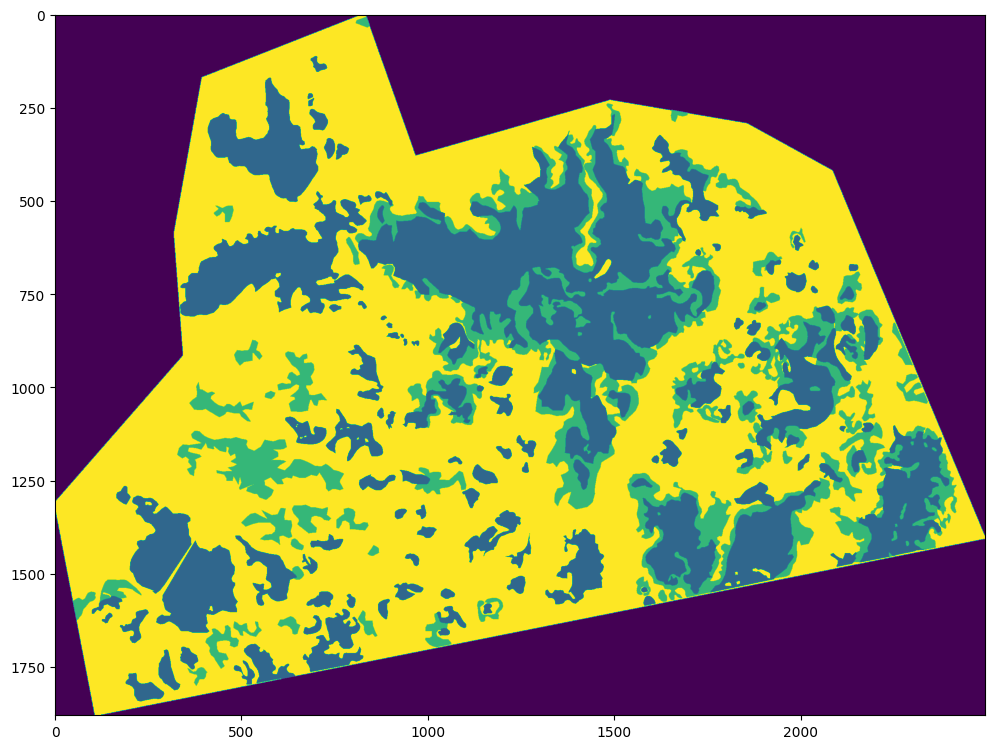

In [ ]:
plt.figure(figsize=(12, 12))
plt.imshow(class_data)

### Alineado de raster con etiquetas de prueba

In [ ]:
def align_raster(src_data, src_transform, src_crs_0, target_transform_0, target_crs_0, dst_resolution_0):
    # Crear un array de ceros con las dimensiones del raster grande (para cada banda)
    aligned_data = np.zeros_like(entropy, dtype=np.uint8)

    # Reproyectar el raster pequeño al tamaño y CRS del raster grande
    reproject(
        src_data,                # Datos de entrada
        aligned_data,            # Datos de salida (vacío, con las dimensiones del raster grande)
        src_transform=src_transform,
        src_crs=src_crs_0,
        src_nodata= 0,

        dst_transform=target_transform_0,
        dst_crs=target_crs_0,
        dst_nodata= 0,
        dst_resolution= dst_resolution_0,
    )
    return aligned_data

# Alinear raster de clase
aligned_class_data = align_raster(class_data, class_transform, class_crs, large_transform, large_crs, large_shape)
class_data = np.zeros_like(entropy, dtype=np.uint8)

# Asignar valores de la primera capa
class_data[aligned_class_data == 1] = 1  # Para agua, asignar 1
class_data[aligned_class_data == 2] = 2  # Para humedales, asignar 2
class_data[aligned_class_data == 3] = 3  # Para vegetacion, asignar 3

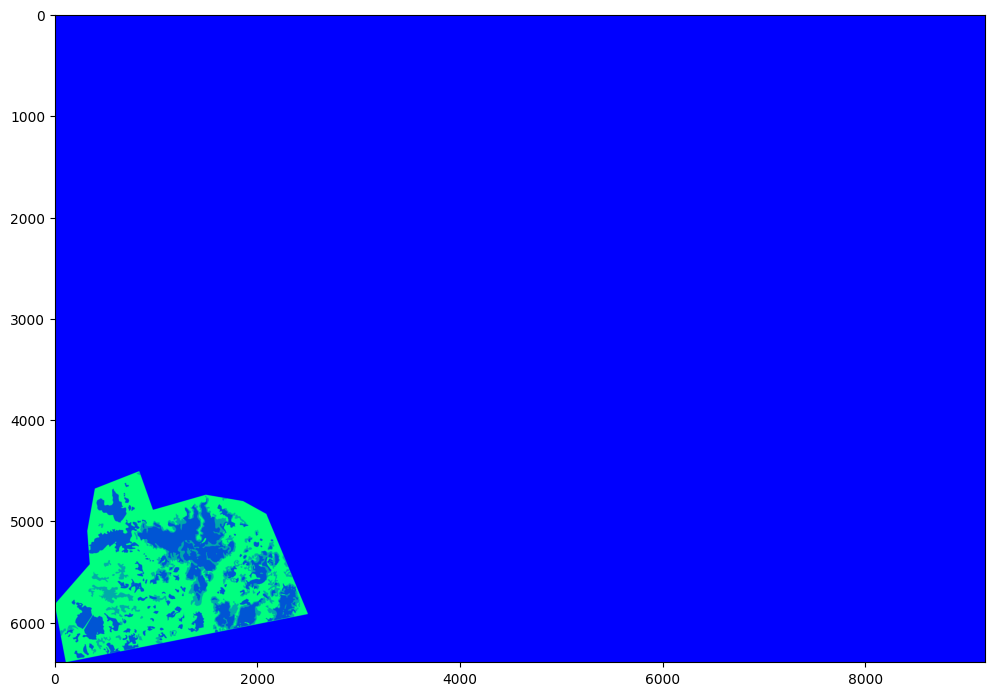

In [ ]:
plt.figure(figsize=(12, 12))
plt.imshow(class_data, cmap='winter')
plt.show()

### Limpieza de datos

In [ ]:
class_data_flat = class_data.ravel()  # Convierte a un vector unidimensional
print(class_data_flat.shape)

(58675771,)


In [ ]:
entropy[entropy == 0] = np.nan
anisotrophy[anisotrophy == 0] = np.nan
alpha[alpha == 0] = np.nan

Promedio datos sin nan 0.05593712627887726
Desviación sin nan 0.05146273225545883


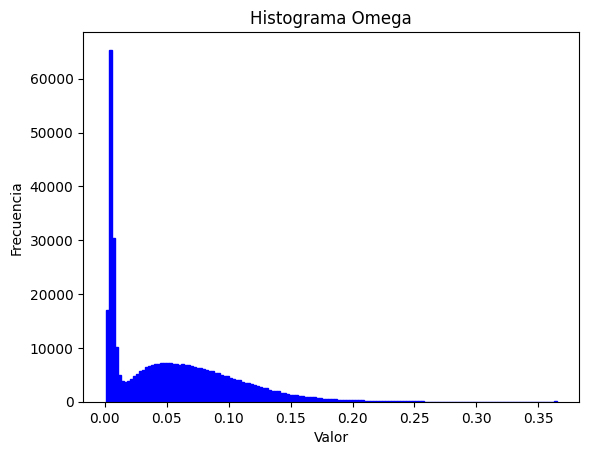

In [ ]:
file_path = '/content/drive/MyDrive/humedales_grdh_rpj_clip.tif'

raw_data = rasterio.open(file_path)

sigma0 = pd.DataFrame(raw_data.read(1))

sigma0_flat = np.array(sigma0).ravel()  # Convierte a un vector unidimensional

sigma0_flat[sigma0_flat == 0] = np.nan

df_sigma0 = pd.DataFrame(sigma0_flat, columns=["Sigma0"])

mean = np.nanmean(sigma0_flat)
std_dev = np.nanstd(sigma0_flat)

print("Promedio datos sin nan {}".format(mean))
print("Desviación sin nan {}".format(std_dev))

# Definir el límite superior e inferior
upper_limit = mean + 6 * std_dev

# Filtra el array a los limites estadisticos para evitar extremos
sigma0_flat[(sigma0_flat > upper_limit)] = upper_limit

# Verificar el resultado

sample = np.random.choice(sigma0_flat, size=1000000, replace=False)

plt.hist(sample, bins=150, color='blue', edgecolor='blue')

# Configurar el título y las etiquetas
plt.title('Histograma Omega')
plt.xlabel('Valor')
plt.ylabel('Frecuencia')

# Mostrar el gráfico
plt.show()

In [ ]:
num_nan = np.isnan(sigma0_flat).sum()
print(sigma0_flat.size)
print(f"Número de valores NaN: {num_nan}")
# Calcular el porcentaje de NaN
porcentaje_nan = (num_nan / sigma0_flat.size) * 100

print(f"Porcentaje de valores NaN: {porcentaje_nan:.2f}%")

58675771
Número de valores NaN: 34050737
Porcentaje de valores NaN: 58.03%


In [ ]:
# Convertir el array a un DataFrame de pandas
sigma0 = pd.DataFrame(sigma0_flat.reshape(6391, 9181))

In [ ]:
data = np.array([entropy, alpha, sigma0])

print(data.shape)

(3, 6391, 9181)


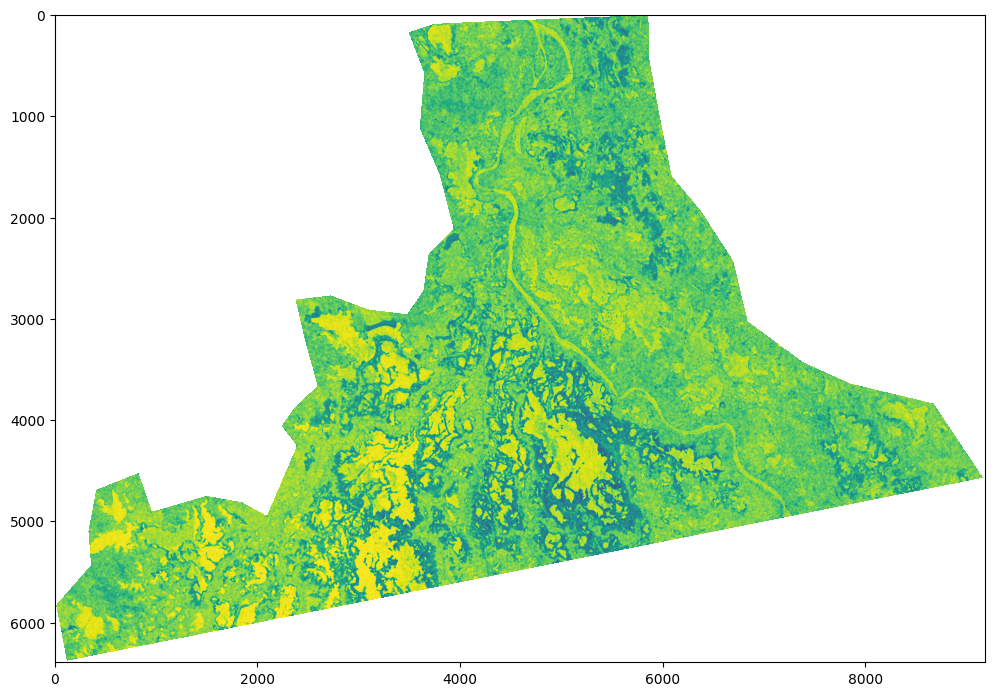

In [ ]:
plt.figure(figsize=(12, 12))
plt.imshow(data[0]) # Grafica de entropía

### Estadística Descriptiva

In [ ]:
height, width = data.shape[1], data.shape[2]
samples = data.reshape(data.shape[0], height * width).T  # Transponer para que las filas sean píxeles

# Crear un DataFrame de pandas con las columnas nombradas
samples_df = pd.DataFrame(samples, columns=["Entropy", "Alpha", "Sigma0"])

# Verificar los cambios
samples_df.describe()

,Entropy,Alpha,Sigma0
count,2.462442e+07,2.462442e+07,2.462503e+07
mean,7.693140e-01,2.320686e+01,5.583492e-02
std,1.485546e-01,6.540907e+00,4.937566e-02
min,5.596698e-02,3.387008e+00,7.531550e-04
25%,7.076238e-01,1.914836e+01,7.174976e-03
50%,7.847418e-01,2.298252e+01,4.834918e-02
75%,8.520163e-01,2.700623e+01,8.692863e-02
max,9.999802e-01,5.540228e+01,3.647135e-01


In [ ]:
samples_df.corr(method='pearson')

,Entropy,Alpha,Sigma0
Entropy,1.000000,0.959474,-0.183358
Alpha,0.959474,1.000000,-0.256734
Sigma0,-0.183358,-0.256734,1.000000


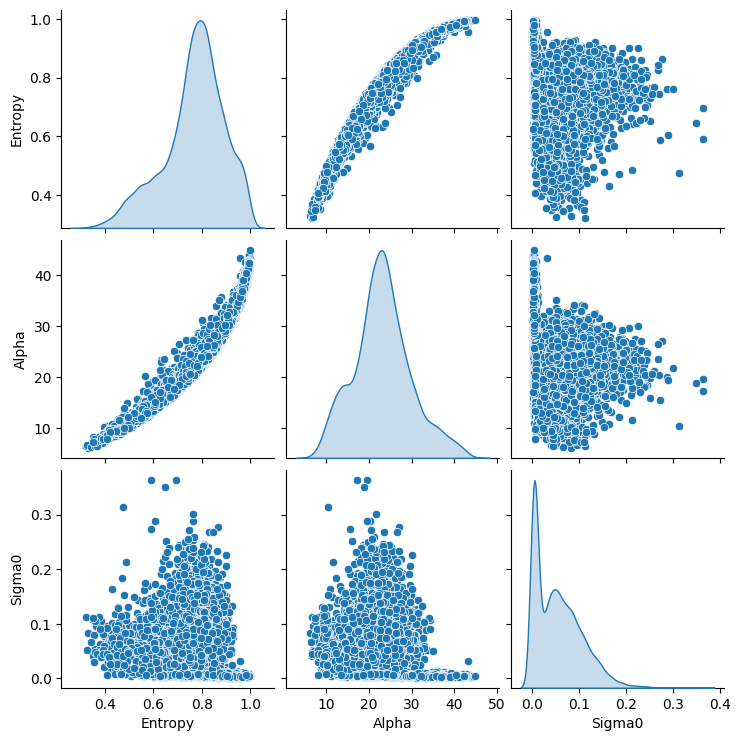

In [ ]:
sns.pairplot(data=samples_df.sample(n=20000, random_state=42, replace=False),diag_kind='kde')

### Preparación datos para clasificación

In [ ]:
# Imprimir el tamaño original del array
print(samples.shape)

# Detectar filas con cualquier valor NaN y eliminar esas filas
empty_mask = np.isnan(samples).any(axis=1)  # Detecta filas con cualquier NaN
samples_clean = samples[~empty_mask]  # Elimina las filas con NaN
class_data_flat_clean = class_data_flat[~empty_mask]  # Elimina los ceros

# Imprimir el tamaño del array limpio
print(samples_clean.shape)
print(class_data_flat_clean.shape)

# Verificar si el array limpio contiene NaN
contiene_nan = np.isnan(samples_clean).any()

# Imprimir si hay NaN en el array limpio
print("¿El array contiene NaN?:", contiene_nan)

(58675771, 3)
(24621766, 3)
(24621766,)
¿El array contiene NaN?: False


In [ ]:
num_samples = 50000  # Ajusta según el rendimiento deseado
sample_indices = np.random.choice(samples_clean.shape[0], num_samples, replace=False)
sample_pixels = samples_clean[sample_indices]
sample_class = class_data_flat_clean[sample_indices]

sample_pixels = sample_pixels[sample_class != 0]
sample_class = sample_class[sample_class != 0]

In [ ]:
print("Valores de muestra (RGB):", sample_pixels[:5])

Valores de muestra (RGB): [[8.5192889e-01 2.7495922e+01 1.0315678e-01]
 [4.3420389e-01 8.3913116e+00 7.7907674e-02]
 [8.5050559e-01 2.5110556e+01 2.6239848e-02]
 [7.6933074e-01 2.1100292e+01 2.7118506e-02]
 [7.7142096e-01 2.3111301e+01 8.8334829e-02]]


### Analisis de separabilidad

In [ ]:
fig = go.Figure(data=[go.Scatter3d(
    x=sample_pixels[:, 0],
    y=sample_pixels[:, 1],
    z=sample_pixels[:, 2],
    mode='markers',
    marker=dict(
        size=2,  # Ajusta el tamaño de los puntos
        color=sample_class,  # Usar class_data para los colores
        colorscale='Viridis',  # Cambia el color con una escala
        opacity=0.8,
        colorbar=dict(title='Clase')  # Mostrar leyenda de color
    )
)])


fig.update_layout(
    title='Gráfico 3D Interactivo',
    scene=dict(
        xaxis_title='Entropía',
        yaxis_title='Alpha',
        zaxis_title='Omega0',
        aspectmode='cube',
        camera=dict(eye=dict(x=0, y=-2, z=0))  # Ajusta la posición de la cámara
    ),
    width=700,
    height=700
)

# Mostrar la figura
fig.show()

In [ ]:
scaler = RobustScaler()
samples_normalized = scaler.fit_transform(samples_clean)

## Modelamiento

In [ ]:
kmeans = MiniBatchKMeans(
                n_clusters=3,  # Fijamos 3 clusters
                batch_size=300,
                max_iter=1,
                init='k-means++',
                random_state=42
            )

kmeans.fit(samples_normalized)
labels = kmeans.labels_

In [ ]:
unique_values = np.unique(labels)
print("Valores únicos:", unique_values)

Valores únicos: [0 1 2]


In [ ]:
samples_class = np.zeros(samples.shape[0], dtype=int)  # Crea vector con 0s

labels = labels + 1

samples_class[~empty_mask] = labels # Reemplaza en el vector las etiquetas clasificadas

samples_class.shape

(58675771,)

In [ ]:
unique_values = np.unique(labels)
print("Valores únicos:", unique_values)

Valores únicos: [1 2 3]


### Corrección de truncamiento de clases

In [ ]:
"""
Nota: Este procedimiento fue diseñado después de conocer los resultados del
algoritmo y reescribe las etiquetas arrojadas por KMeans para que sean consistentes
con las etiquetas preestablecidas en el área de estudio.
"""

class_sizes = {
    0: np.where(samples_class == 0)[0].shape[0],
    1: np.where(samples_class == 1)[0].shape[0],
    2: np.where(samples_class == 2)[0].shape[0],
    3: np.where(samples_class == 3)[0].shape[0]
}

# Ordenar las clases según su tamaño de mayor a menor
sorted_classes = sorted(class_sizes.items(), key=lambda x: x[1], reverse=True)

# Crear un nuevo mapeo según el orden deseado
# Clase más grande -> 0, siguiente -> 3, siguiente -> 1, más pequeña -> 2
new_class_map = {sorted_classes[0][0]: 0,  # Clase más grande
                 sorted_classes[1][0]: 3,  # Segunda más grande
                 sorted_classes[2][0]: 1,  # Tercera más grande
                 sorted_classes[3][0]: 2}  # Más pequeña

# Reescribir samples_class según el mapeo
new_samples_class = np.vectorize(new_class_map.get)(samples_class)

<Figure size 1200x1200 with 0 Axes>

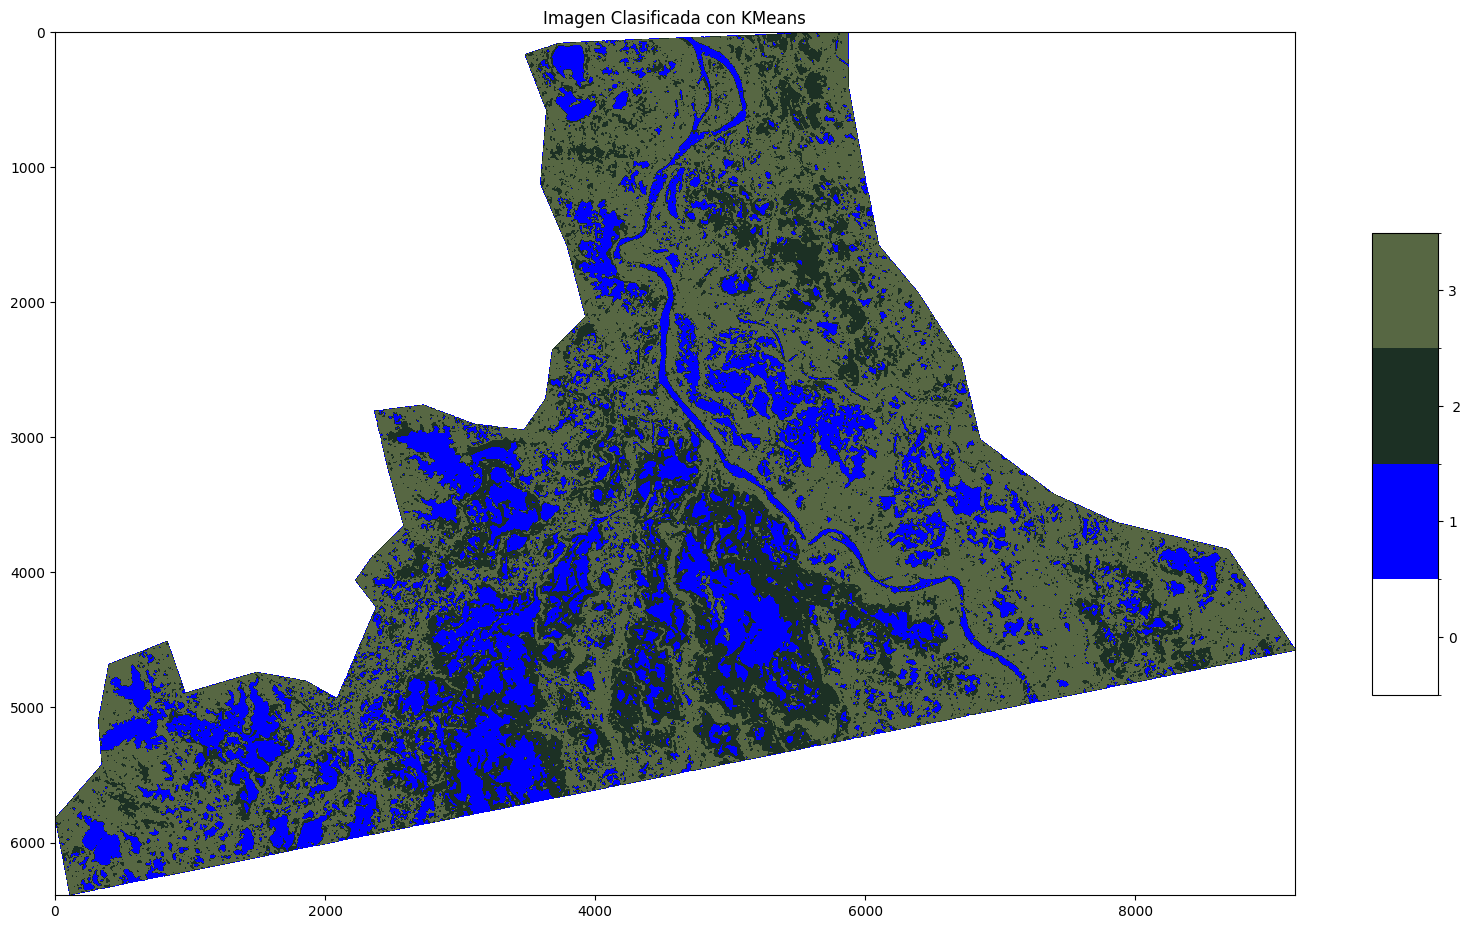

In [ ]:
plt.figure(figsize=(12, 12))

colors = ['white', '#707e5a', '#576743', '#34563d', 'blue', '#1c3024', '#1c3024']  # Ajusta según tus necesidades [No data, Veg. Liviana, Veg. Media, Veg. Pesada, Agua, Humedal, No Implementado]

colors = ['white', 'blue','#1c3024', '#576743','#576743']  # Ajusta según tus necesidades [No data, Veg. Liviana, Humedal, Agua]

cmap = ListedColormap(colors)

norm = BoundaryNorm(np.arange(len(colors)) - 0.5, cmap.N)

fig, ax = plt.subplots(figsize=(20, 20))

im = ax.imshow(new_samples_class.reshape((6391, 9181)), cmap=cmap, norm=norm)

cbar = fig.colorbar(im, ax=ax, ticks=np.arange(len(colors)), shrink=0.3, aspect=7)
cbar.ax.set_yticklabels(["0","1"," 2 ","3",'No Implementado'])  # Etiquetas personalizadas

plt.title('Imagen Clasificada con KMeans')

plt.show()

## Evaluación Modelo

### Filtrado de etiquetas a exclusivamente datos de prueba

In [ ]:
filtered_class_data = class_data_flat[(class_data_flat == 1) | (class_data_flat == 2) | (class_data_flat == 3)]

# Si también necesitas las posiciones (índices) de estos valores filtrados:
filtered_indices = np.where((class_data_flat == 1) | (class_data_flat == 2) | (class_data_flat == 3))[0]

# Si deseas obtener los valores de los puntos correspondientes en sample_pixels (o cualquier otro array asociado):
filtered_labels = new_samples_class[filtered_indices]
filtered_labels.shape


(2938460,)

### Cálculo de áreas clasificadas según su clase

In [ ]:
water_pixel_size = np.where((new_samples_class == 1))[0].shape[0]
wetlands_pixel_size = np.where((new_samples_class == 2))[0].shape[0]
veg_pixel_size = np.where((new_samples_class == 3))[0].shape[0]

print("Para la clase agua se encontraron {} pixeles de {} pixeles en total, un {}% del área de estudio".format(water_pixel_size,labels.shape[0],water_pixel_size*100/labels.shape[0]))
print("Para la clase humedales se encontraron {} pixeles de {} pixeles en total, un {}% del área de estudio".format(wetlands_pixel_size,labels.shape[0],wetlands_pixel_size*100/labels.shape[0]))
print("Para la clase vegetación se encontraron {} pixeles de {} pixeles en total, un {}% del área de estudio".format(veg_pixel_size,labels.shape[0],veg_pixel_size*100/labels.shape[0]))
print("\nEl área total de agua es {} km^2 ".format(water_pixel_size/10000))
print("El área total de humedales es {} km^2 ".format(wetlands_pixel_size/10000))
print("El área total de vegetacion es {} km^2 ".format(veg_pixel_size/10000))

Para la clase agua se encontraron 6490155 pixeles de 24621766 pixeles en total, un 26.35942117230746% del área de estudio
Para la clase humedales se encontraron 4767739 pixeles de 24621766 pixeles en total, un 19.363919712339076% del área de estudio
Para la clase vegetación se encontraron 13363872 pixeles de 24621766 pixeles en total, un 54.27665911535346% del área de estudio

El área total de agua es 649.0155 km^2 
El área total de humedales es 476.7739 km^2 
El área total de vegetacion es 1336.3872 km^2 


### Matriz de Confusión

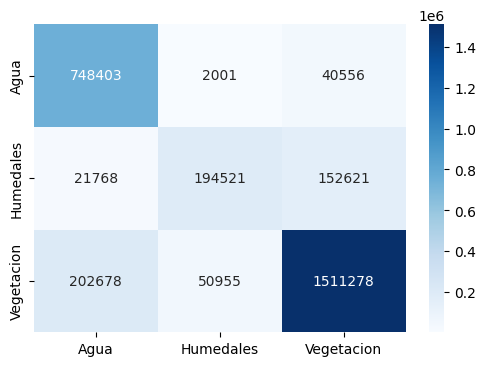

In [ ]:
# Calcular la matriz de confusión solo para las clases 1 y 2
conf_matrix = confusion_matrix(filtered_class_data, filtered_labels, labels=[1, 2, 3])

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Agua", "Humedales", "Vegetacion"], yticklabels=["Agua", "Humedales", "Vegetacion"])
plt.show()

### Métricas de desempeño

In [ ]:
metrics_per_class = {}
for class_label in [1, 2, 3]:
    TP = conf_matrix[class_label - 1][class_label - 1]  # Verdaderos positivos (diagonal)
    FP = conf_matrix[:, class_label - 1].sum() - TP  # Falsos positivos (suma de columna - TP)
    FN = conf_matrix[class_label - 1].sum() - TP  # Falsos negativos (suma de fila - TP)
    TN = conf_matrix.sum() - (TP + FP + FN)  # Verdaderos negativos

    # Calcular precisión
    precision = TP / (TP + FP) if TP + FP != 0 else 0

    # Calcular recall
    recall = TP / (TP + FN) if TP + FN != 0 else 0

    # Calcular F1 score
    if precision + recall != 0:
        f1_score = 2 * (precision * recall) / (precision + recall)
    else:
        f1_score = 0

    metrics_per_class[class_label] = {
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1_score
    }

# Mostrar métricas por clase
for class_label, metrics in metrics_per_class.items():
    print(f"Clase {class_label}:")
    print(f"  Precisión: {metrics['Precision']:.4f}")
    print(f"  Recall: {metrics['Recall']:.4f}")
    print(f"  F1 Score: {metrics['F1 Score']:.4f}")
    print()

Clase 1:
  Precisión: 0.7693
  Recall: 0.9462
  F1 Score: 0.8486

Clase 2:
  Precisión: 0.7860
  Recall: 0.5273
  F1 Score: 0.6312

Clase 3:
  Precisión: 0.8867
  Recall: 0.8563
  F1 Score: 0.8712



### Clasificación Final con Hiperparámetros Optimizados

In [ ]:
num_samples = 5000  # Ajusta según el rendimiento deseado
sample_indices = np.random.choice(samples_clean.shape[0], num_samples, replace=False)
sample_pixels = samples_clean[sample_indices]
sample_class = labels[sample_indices]

sample_pixels = sample_pixels[sample_class != 0]
sample_class = sample_class[sample_class != 0]

fig = go.Figure(data=[go.Scatter3d(
    x=sample_pixels[:, 0],
    y=sample_pixels[:, 1],
    z=sample_pixels[:, 2],
    mode='markers',
    marker=dict(
        size=2,  # Ajusta el tamaño de los puntos
        color=sample_class,  # Usar class_data para los colores
        colorscale='Viridis',  # Cambia el color con una escala
        opacity=0.8,
        colorbar=dict(title='Clase')  # Mostrar leyenda de color
    )
)])


fig.update_layout(
    title='Gráfico 3D Interactivo',
    scene=dict(
        xaxis_title='Entropía',
        yaxis_title='Alpha',
        zaxis_title='Omega0',
        aspectmode='cube',
        camera=dict(eye=dict(x=0, y=-2, z=0))  # Ajusta la posición de la cámara
    ),
    width=700,
    height=700
)

# Mostrar la figura
fig.show()

### DEBUG - Optimización de Hiperparámetros

In [ ]:

#NOTA: Esta sección sirvió unicamente para encontrar el mejor set de parametros de MiniBatchKMeans para mejor precisión en clasificación

from scipy.optimize import linear_sum_assignment
from sklearn.metrics import precision_score

batch_sizes = [299,300,301]
max_iters = [1,2,3]
init_methods = ["k-means++"]

# Métricas y resultados
best_score = -1
best_params = None
best_labels = None

# Clase objetivo
target_class = 2

for batch_size in batch_sizes:
    for max_iter in max_iters:
        for init_method in init_methods:
            # Modelo MiniBatchKMeans
            kmeans = MiniBatchKMeans(
                n_clusters=3,  # Fijamos 3 clusters
                batch_size=batch_size,
                max_iter=max_iter,
                init=init_method,
                random_state=42
            )
            # Entrenamiento
            kmeans.fit(samples_normalized)
            labels = kmeans.labels_

            # Relabel clusters para alinear con las clases verdaderas
            samples_class = np.zeros(samples.shape[0], dtype=int)  # Crea vector con 0s

            labels = labels + 1

            samples_class[~empty_mask] = labels # Reemplaza en el vector las etiquetas clasificadas

            # Si deseas obtener los valores de los puntos correspondientes en sample_pixels (o cualquier otro array asociado):
            filtered_labels = samples_class[filtered_indices]

            cm = confusion_matrix(filtered_class_data, filtered_labels)
            row_ind, col_ind = linear_sum_assignment(-cm)  # Maximiza la asignación
            label_mapping = dict(zip(col_ind, row_ind))
            mapped_labels = np.array([label_mapping[label] for label in filtered_labels])

            # Evaluación: Precisión para la clase 2
            precision = precision_score(
                filtered_class_data == target_class, mapped_labels == target_class
            )

            # Actualizar mejores resultados
            if precision > best_score:
                best_score = precision
                best_params = {
                    "batch_size": batch_size,
                    "max_iter": max_iter,
                    "init_method": init_method,
                }
                best_labels = samples_class

# Resultados finales
print("Mejor precisión para la clase 2:", best_score)
print("Mejores parámetros:", best_params)

Mejor precisión para la clase 2: 0.7860164782989935
Mejores parámetros: {'batch_size': 300, 'max_iter': 1, 'init_method': 'k-means++'}


In [ ]:
kmeans = MiniBatchKMeans(
                n_clusters=3,  # Fijamos 3 clusters
                batch_size=300,
                max_iter=1,
                init='k-means++',
                random_state=42
            )

kmeans.fit(samples_normalized)
labels = kmeans.labels_

In [ ]:
unique_values = np.unique(labels)
print("Valores únicos:", unique_values)

Valores únicos: [0 1 2]


In [ ]:
samples_class = np.zeros(samples.shape[0], dtype=int)  # Crea vector con 0s

labels = labels + 1

samples_class[~empty_mask] = labels # Reemplaza en el vector las etiquetas clasificadas

samples_class.shape

(58675771,)

In [ ]:
"""
Nota: Este procedimiento fue diseñado después de conocer los resultados del
algoritmo y reescribe las etiquetas arrojadas por KMeans para que sean consistentes
con las etiquetas preestablecidas en el área de estudio.
"""

class_sizes = {
    0: np.where(samples_class == 0)[0].shape[0],
    1: np.where(samples_class == 1)[0].shape[0],
    2: np.where(samples_class == 2)[0].shape[0],
    3: np.where(samples_class == 3)[0].shape[0]
}

# Ordenar las clases según su tamaño de mayor a menor
sorted_classes = sorted(class_sizes.items(), key=lambda x: x[1], reverse=True)

# Crear un nuevo mapeo según el orden deseado
# Clase más grande -> 0, siguiente -> 3, siguiente -> 1, más pequeña -> 2
new_class_map = {sorted_classes[0][0]: 0,  # Clase más grande
                 sorted_classes[1][0]: 3,  # Segunda más grande
                 sorted_classes[2][0]: 1,  # Tercera más grande
                 sorted_classes[3][0]: 2}  # Más pequeña

# Reescribir samples_class según el mapeo
new_samples_class = np.vectorize(new_class_map.get)(samples_class)

<Figure size 1200x1200 with 0 Axes>

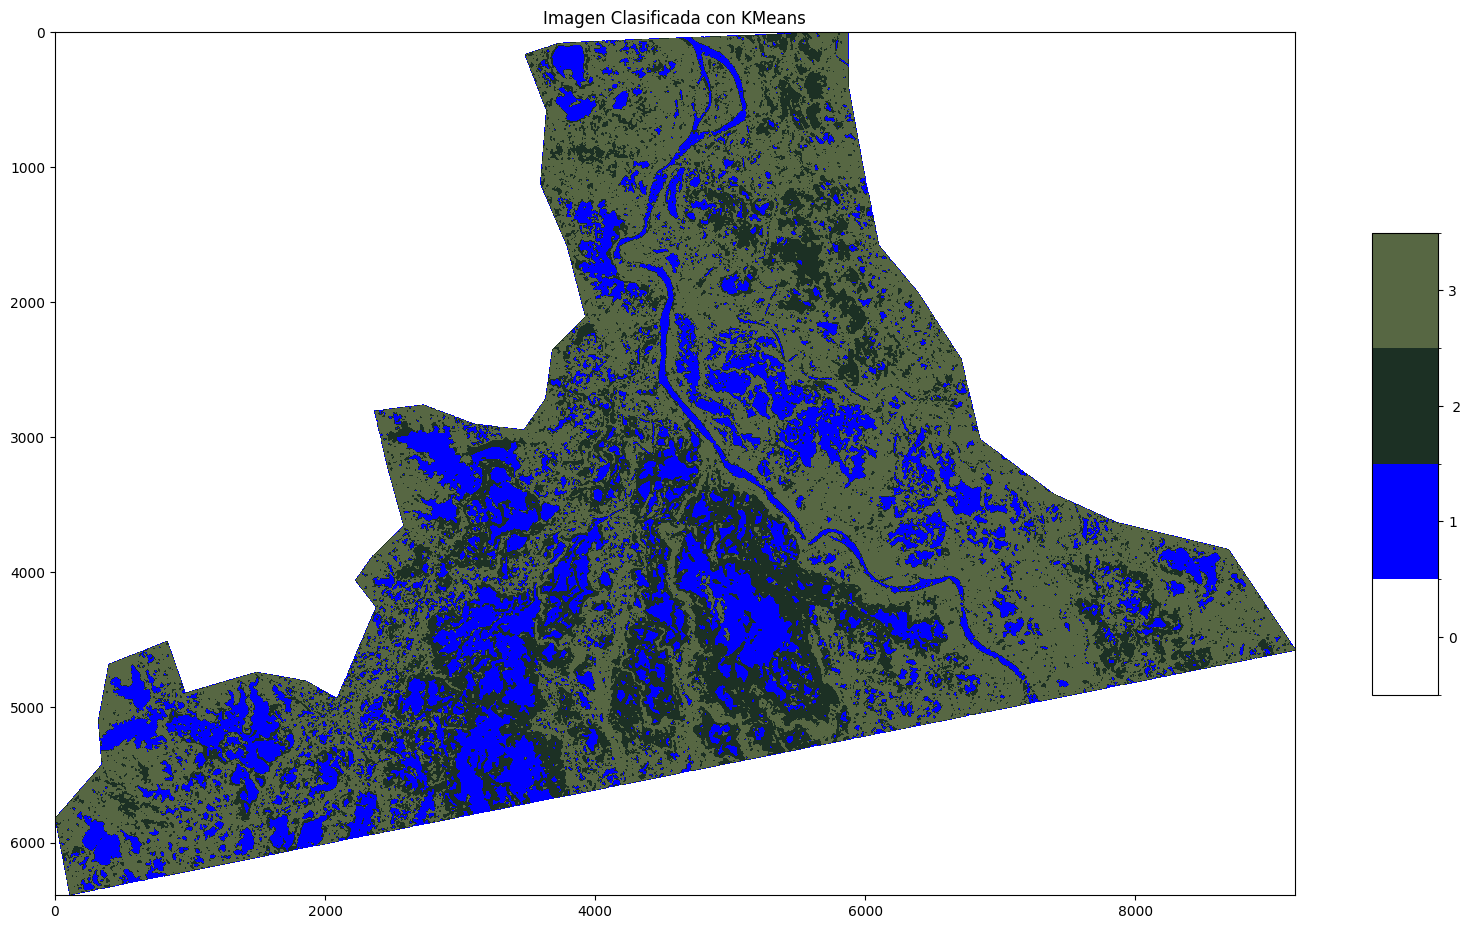

In [ ]:
plt.figure(figsize=(12, 12))

colors = ['white', '#707e5a', '#576743', '#34563d', 'blue', '#1c3024', '#1c3024']  # Ajusta según tus necesidades [No data, Veg. Liviana, Veg. Media, Veg. Pesada, Agua, Humedal, No Implementado]

colors = ['white', 'blue','#1c3024', '#576743','#576743']  # Ajusta según tus necesidades [No data, Veg. Liviana, Humedal, Agua]

cmap = ListedColormap(colors)

norm = BoundaryNorm(np.arange(len(colors)) - 0.5, cmap.N)

fig, ax = plt.subplots(figsize=(20, 20))

im = ax.imshow(new_samples_class.reshape((6391, 9181)), cmap=cmap, norm=norm)

cbar = fig.colorbar(im, ax=ax, ticks=np.arange(len(colors)), shrink=0.3, aspect=7)
cbar.ax.set_yticklabels(["0","1"," 2 ","3",'No Implementado'])  # Etiquetas personalizadas

plt.title('Imagen Clasificada con KMeans')

plt.show()

In [ ]:
filtered_class_data = class_data_flat[(class_data_flat == 1) | (class_data_flat == 2) | (class_data_flat == 3)]

# Si también necesitas las posiciones (índices) de estos valores filtrados:
filtered_indices = np.where((class_data_flat == 1) | (class_data_flat == 2) | (class_data_flat == 3))[0]

# Si deseas obtener los valores de los puntos correspondientes en sample_pixels (o cualquier otro array asociado):
filtered_labels = new_samples_class[filtered_indices]
filtered_labels.shape


(2938460,)

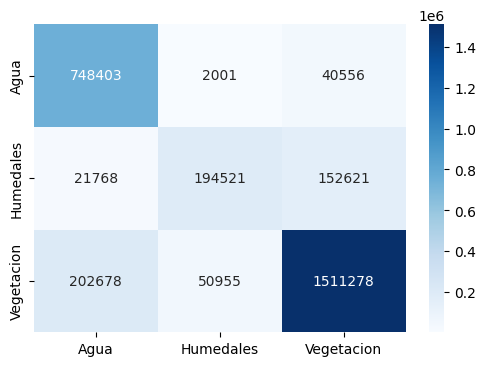

In [ ]:
# Calcular la matriz de confusión solo para las clases 1 y 2
conf_matrix = confusion_matrix(filtered_class_data, filtered_labels, labels=[1, 2, 3])

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Agua", "Humedales", "Vegetacion"], yticklabels=["Agua", "Humedales", "Vegetacion"])
plt.show()

In [ ]:
metrics_per_class = {}
for class_label in [1, 2, 3]:
    TP = conf_matrix[class_label - 1][class_label - 1]  # Verdaderos positivos (diagonal)
    FP = conf_matrix[:, class_label - 1].sum() - TP  # Falsos positivos (suma de columna - TP)
    FN = conf_matrix[class_label - 1].sum() - TP  # Falsos negativos (suma de fila - TP)
    TN = conf_matrix.sum() - (TP + FP + FN)  # Verdaderos negativos

    # Calcular precisión
    precision = TP / (TP + FP) if TP + FP != 0 else 0

    # Calcular recall
    recall = TP / (TP + FN) if TP + FN != 0 else 0

    # Calcular F1 score
    if precision + recall != 0:
        f1_score = 2 * (precision * recall) / (precision + recall)
    else:
        f1_score = 0

    metrics_per_class[class_label] = {
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1_score
    }

# Mostrar métricas por clase
for class_label, metrics in metrics_per_class.items():
    print(f"Clase {class_label}:")
    print(f"  Precisión: {metrics['Precision']:.4f}")
    print(f"  Recall: {metrics['Recall']:.4f}")
    print(f"  F1 Score: {metrics['F1 Score']:.4f}")
    print()

Clase 1:
  Precisión: 0.7693
  Recall: 0.9462
  F1 Score: 0.8486

Clase 2:
  Precisión: 0.7860
  Recall: 0.5273
  F1 Score: 0.6312

Clase 3:
  Precisión: 0.8867
  Recall: 0.8563
  F1 Score: 0.8712

